# Transient microkinetics

Integrate the surface coverages in time with discopt's orthogonal-collocation DAE solver, starting from a bare surface, and confirm the long-time limit matches the steady-state solver.

In [1]:
import numpy as np, discopt.mkm as mk
from discopt.mkm.examples import co_oxidation
m, reactor = co_oxidation(T=500.0)
COs, Os = m._by_name['CO*'], m._by_name['O*']
m

#,reaction,kinetics,type
1,CO + Pt ⇌ CO∗,"A=10000, Ea=0",reversible
2,O2 + 2 Pt ⇌ 2 O∗,"A=10000, Ea=0",reversible
3,CO∗ + O∗ ⇌ CO2 + 2 Pt,"A=1e+08, Ea=0.7",reversible


## Integrate from a bare surface

In [2]:
tr = mk.solve_transient(m, reactor, t_span=(0.0, 0.005), theta0={COs: 0.0, Os: 0.0}, nfe=40, ncp=3)
print('status:', tr.status)
print(f'  final theta[CO*] = {tr.final_coverage(COs):.4f}')
print(f'  final theta[O*]  = {tr.final_coverage(Os):.4f}')

status: optimal
  final theta[CO*] = 0.5852
  final theta[O*]  = 0.2314


## Compare to the steady-state solver

In [3]:
ss = mk.solve_steady_state(m, reactor)
print(f'steady-state theta[CO*] = {ss.coverage(COs):.4f}')
print(f'steady-state theta[O*]  = {ss.coverage(Os):.4f}')

steady-state theta[CO*] = 0.5852
steady-state theta[O*]  = 0.2314


## Plot the transient approach to steady state

`times()` and `coverage()` return aligned 1D arrays, so the trajectory plots directly. The coverages relax from the bare surface to the values the steady-state solver returns (dotted lines).

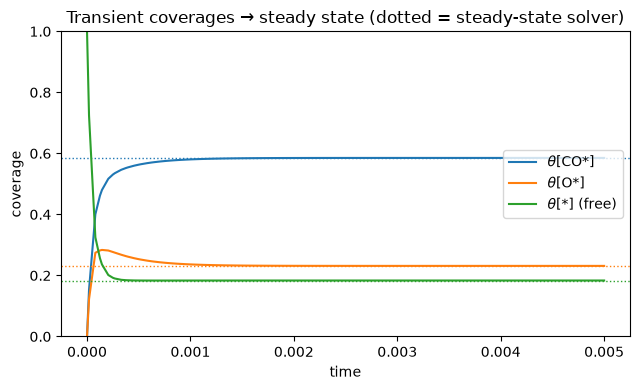

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
t = tr.times()
yCO, yO = tr.coverage(COs), tr.coverage(Os)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(t, yCO, 'C0', label=r'$\theta$[CO*]'); ax.axhline(ss.coverage(COs), color='C0', ls=':', lw=1)
ax.plot(t, yO, 'C1', label=r'$\theta$[O*]'); ax.axhline(ss.coverage(Os), color='C1', ls=':', lw=1)
ax.plot(t, 1.0 - yCO - yO, 'C2', label=r'$\theta$[*] (free)')
ax.axhline(ss.free_coverage(m.sites[0]), color='C2', ls=':', lw=1)
ax.set_xlabel('time'); ax.set_ylabel('coverage'); ax.set_ylim(0, 1)
ax.legend(loc='center right')
ax.set_title('Transient coverages \u2192 steady state (dotted = steady-state solver)')
fig.tight_layout()
